# Retail Supply Chain Analytics
## Daily Demand Prediction & Supply Chain Optimization
### NTI Final Project

 # 1 Import Libraries

In [6]:


import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import GradientBoostingRegressor
# Display Settings
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

#  2 Load Data

In [7]:
df = pd.read_csv("/content/Retail_Supply_Chain_Analytics_Dataset (1).csv")

In [8]:
df.head()

,Product_ID,Product_Category,Brand,SKU,Current_Stock,Reorder_Level,Safety_Stock,Inventory_Turnover,Supplier_ID,Supplier_Rating,Lead_Time_Days,Warehouse_ID,Warehouse_Location,Storage_Capacity,Utilization_Rate,Units_Sold,Daily_Demand,Monthly_Demand,Seasonal_Demand_Index,Shipping_Cost_USD,Transportation_Mode,Delivery_Time_Days,On_Time_Delivery_Rate,Product_Cost_USD,Selling_Price_USD,Revenue_USD,Profit_USD,Stockout_Risk,Overstock_Risk,Supply_Disruption_Risk,Date,Month,Quarter,Year,Demand_Forecast,Inventory_Optimization_Score,Supplier_Performance_Score,Supply_Chain_Efficiency,Sustainability_Score,Predicted_Reorder_Quantity,Operational_Risk_Score
0,PRD0000001,Fashion,BrandD,SKU191221,660,146,317,16.13,SUP1114,2.81,50,WH052,North,69540,54.66,3424,430,3773,47.77,394.22,Road,28,23.93,703.03,3631.04,465219.80,80638.70,46.62,83.03,65.11,2025-07-05,7,3,2025,6859,13.00,62.03,35.34,19.86,3949,3.99
1,PRD0000002,Home,BrandB,SKU116795,1681,176,219,1.11,SUP2811,2.77,41,WH054,West,3503,42.78,1366,395,10102,63.52,286.44,Sea,8,53.91,804.40,430.46,109158.38,64865.86,76.10,42.62,88.91,2025-09-11,9,3,2025,438,98.14,53.57,56.87,61.67,3820,39.96
2,PRD0000003,Electronics,BrandC,SKU344678,8195,714,109,8.38,SUP0815,5.00,21,WH286,West,25531,11.28,2761,169,13036,76.47,49.90,Air,11,36.01,885.40,3570.20,372305.66,78854.06,49.59,78.33,29.85,2025-04-05,4,2,2025,7961,17.37,6.47,87.55,35.81,1899,87.99
3,PRD0000004,Food,BrandC,SKU674236,4312,320,155,3.19,SUP0201,1.57,40,WH312,North,13589,58.65,1954,200,7154,77.86,202.86,Air,11,26.66,875.63,2479.53,293493.26,69102.68,75.72,1.69,44.59,2023-12-07,12,4,2023,19091,30.86,76.55,27.23,36.13,1288,70.06
4,PRD0000005,Fashion,BrandA,SKU327399,4067,981,222,5.85,SUP3354,1.53,63,WH336,West,36839,66.77,2875,417,3959,71.22,152.02,Road,15,71.29,36.05,3998.68,131952.55,99113.04,7.09,36.53,27.60,2023-06-13,6,2,2023,18036,31.06,19.25,20.44,92.92,4278,9.15


# 3 Data Understanding

In [9]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 200000
Columns : 41


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Product_ID                    200000 non-null  object 
 1   Product_Category              200000 non-null  object 
 2   Brand                         200000 non-null  object 
 3   SKU                           200000 non-null  object 
 4   Current_Stock                 200000 non-null  int64  
 5   Reorder_Level                 200000 non-null  int64  
 6   Safety_Stock                  200000 non-null  int64  
 7   Inventory_Turnover            200000 non-null  float64
 8   Supplier_ID                   200000 non-null  object 
 9   Supplier_Rating               200000 non-null  float64
 10  Lead_Time_Days                200000 non-null  int64  
 11  Warehouse_ID                  200000 non-null  object 
 12  Warehouse_Location            200000 non-nul

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Current_Stock,200000.0,5001.120900,2891.173975,0.00,2495.0000,5000.000,7507.0000,9999.00
Reorder_Level,200000.0,505.412565,286.002597,10.00,257.0000,507.000,754.0000,999.00
Safety_Stock,200000.0,254.189080,141.454268,10.00,131.0000,254.000,376.0000,499.00
Inventory_Turnover,200000.0,10.017377,5.780697,0.00,5.0100,10.040,15.0200,20.00
Supplier_Rating,200000.0,3.000134,1.152276,1.00,2.0000,3.000,4.0000,5.00
Lead_Time_Days,200000.0,44.990320,25.684268,1.00,23.0000,45.000,67.0000,89.00
Storage_Capacity,200000.0,50435.756755,28589.927260,1001.00,25655.0000,50278.000,75206.0000,99998.00
Utilization_Rate,200000.0,50.000285,28.859697,0.00,25.0400,50.010,74.9300,100.00
Units_Sold,200000.0,2500.743275,1445.086336,0.00,1253.0000,2496.000,3755.0000,4999.00
Daily_Demand,200000.0,249.691480,144.627209,0.00,124.0000,249.000,375.0000,499.00


In [12]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

,0


# Data Cleaning

  # 4.1 Missing Values

In [13]:
df.isnull().sum().sort_values(ascending=False)

,0
Product_ID,0
Product_Category,0
Brand,0
SKU,0
Current_Stock,0
Reorder_Level,0
Safety_Stock,0
Inventory_Turnover,0
Supplier_ID,0
Supplier_Rating,0


In [14]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})

missing_df = missing_df[missing_df["Missing Values"] > 0]

missing_df.sort_values(by="Percentage", ascending=False)

,Missing Values,Percentage


# 4.2 Duplicate Values

In [15]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [16]:
df.dtypes

,0
Product_ID,object
Product_Category,object
Brand,object
SKU,object
Current_Stock,int64
Reorder_Level,int64
Safety_Stock,int64
Inventory_Turnover,float64
Supplier_ID,object
Supplier_Rating,float64


In [17]:
df["Date"] = pd.to_datetime(df["Date"])

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   Product_ID                    200000 non-null  object        
 1   Product_Category              200000 non-null  object        
 2   Brand                         200000 non-null  object        
 3   SKU                           200000 non-null  object        
 4   Current_Stock                 200000 non-null  int64         
 5   Reorder_Level                 200000 non-null  int64         
 6   Safety_Stock                  200000 non-null  int64         
 7   Inventory_Turnover            200000 non-null  float64       
 8   Supplier_ID                   200000 non-null  object        
 9   Supplier_Rating               200000 non-null  float64       
 10  Lead_Time_Days                200000 non-null  int64         
 11  Warehouse_ID 

# 4.4 Outlier Detection

In [19]:
numerical_columns = df.select_dtypes(include=np.number).columns

numerical_columns

Index(['Current_Stock', 'Reorder_Level', 'Safety_Stock', 'Inventory_Turnover',
       'Supplier_Rating', 'Lead_Time_Days', 'Storage_Capacity',
       'Utilization_Rate', 'Units_Sold', 'Daily_Demand', 'Monthly_Demand',
       'Seasonal_Demand_Index', 'Shipping_Cost_USD', 'Delivery_Time_Days',
       'On_Time_Delivery_Rate', 'Product_Cost_USD', 'Selling_Price_USD',
       'Revenue_USD', 'Profit_USD', 'Stockout_Risk', 'Overstock_Risk',
       'Supply_Disruption_Risk', 'Month', 'Quarter', 'Year', 'Demand_Forecast',
       'Inventory_Optimization_Score', 'Supplier_Performance_Score',
       'Supply_Chain_Efficiency', 'Sustainability_Score',
       'Predicted_Reorder_Quantity', 'Operational_Risk_Score'],
      dtype='object')

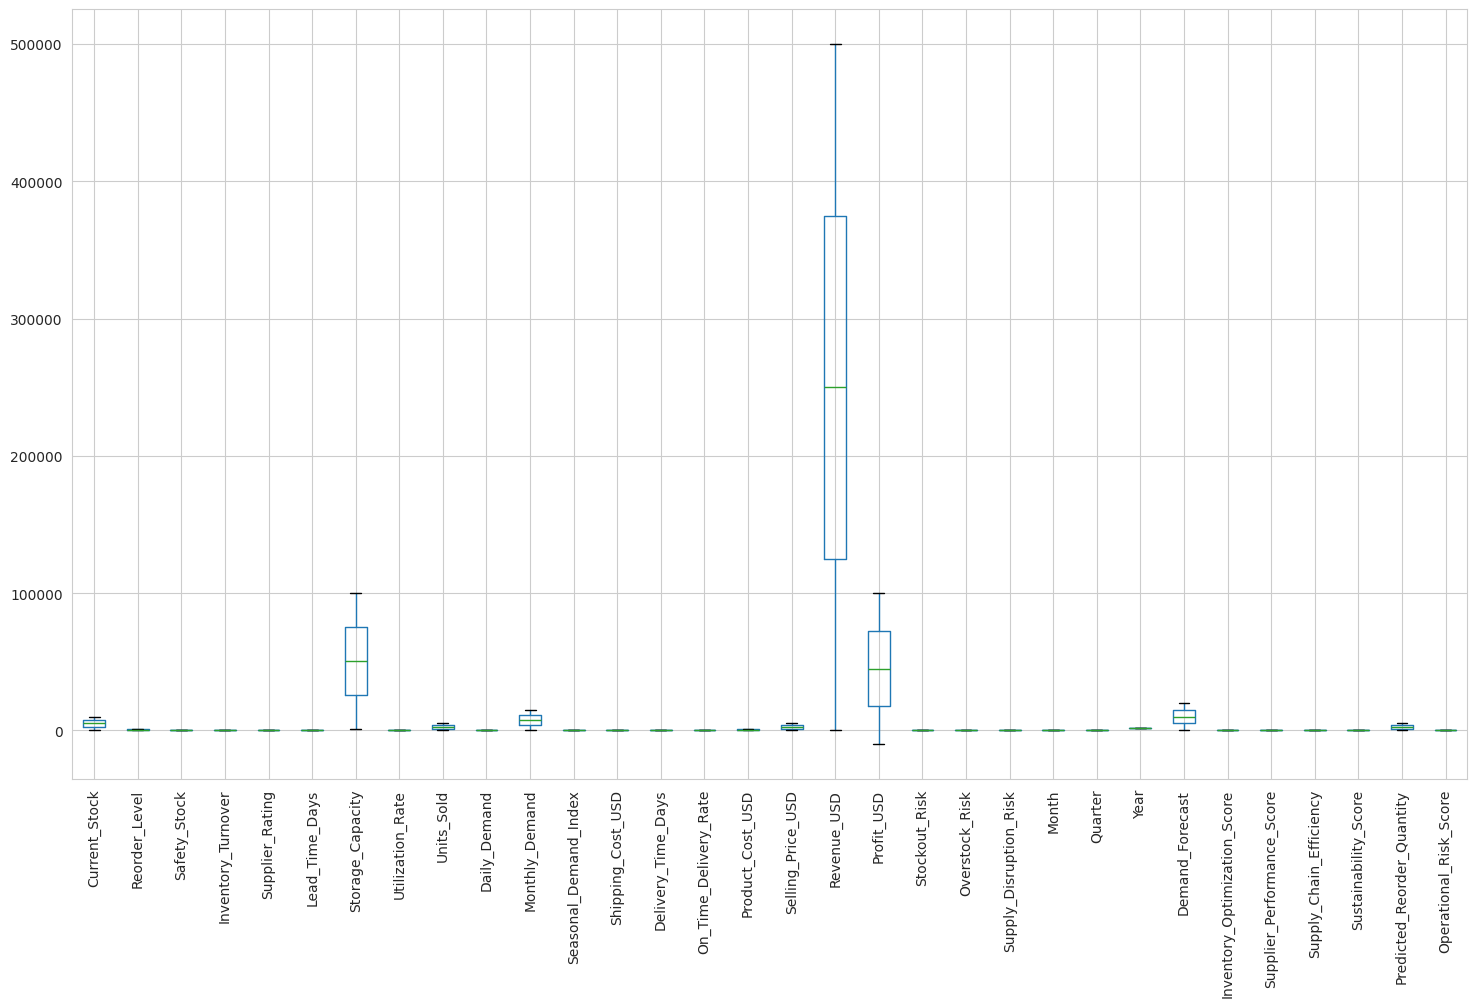

In [20]:
plt.figure(figsize=(18,10))

df[numerical_columns].boxplot(rot=90)

plt.show()

In [21]:
outliers = {}

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = df[(df[col] < lower) | (df[col] > upper)].shape[0]

    outliers[col] = count

outlier_df = pd.DataFrame(
    outliers.items(),
    columns=["Column", "Outliers Count"]
)

outlier_df.sort_values(
    by="Outliers Count",
    ascending=False
)

,Column,Outliers Count
0,Current_Stock,0
1,Reorder_Level,0
2,Safety_Stock,0
3,Inventory_Turnover,0
4,Supplier_Rating,0
5,Lead_Time_Days,0
6,Storage_Capacity,0
7,Utilization_Rate,0
8,Units_Sold,0
9,Daily_Demand,0


# 5 Feature Engineering

# 5.1 Profit Margin

In [22]:
df["Profit_Margin"] = np.where(
    df["Revenue_USD"] == 0,
    0,
    (df["Profit_USD"] / df["Revenue_USD"]) * 100
)

In [23]:
df["Profit_Margin"].head()

,Profit_Margin
0,17.333463
1,59.423619
2,21.179925
3,23.544895
4,75.112637


 # 5.2  Stock Coverage Days

In [24]:
df["Stock_Coverage_Days"] = np.where(
    df["Daily_Demand"] == 0,
    0,
    df["Current_Stock"] / df["Daily_Demand"]
)

In [25]:
df["Stock_Coverage_Days"].head()

,Stock_Coverage_Days
0,1.534884
1,4.255696
2,48.491124
3,21.560000
4,9.752998


# 5.3 Operational Risk Score

In [26]:
df["Revenue_Per_Unit"] = np.where(
    df["Units_Sold"] == 0,
    0,
    df["Revenue_USD"] / df["Units_Sold"]
)

In [27]:
df["Revenue_Per_Unit"].head()

,Revenue_Per_Unit
0,135.870269
1,79.910966
2,134.844498
3,150.201259
4,45.896539


In [28]:
df[[
    "Profit_Margin",
    "Stock_Coverage_Days",
    "Revenue_Per_Unit"
]].head()

,Profit_Margin,Stock_Coverage_Days,Revenue_Per_Unit
0,17.333463,1.534884,135.870269
1,59.423619,4.255696,79.910966
2,21.179925,48.491124,134.844498
3,23.544895,21.560000,150.201259
4,75.112637,9.752998,45.896539


# 6 Exploratory Data Analysis (EDA)

# 6.1 Revenue vs Profit Correlation (Plotly)

In [29]:
correlation = df["Revenue_USD"].corr(df["Profit_USD"])

print(f"Correlation between Revenue and Profit: {correlation:.3f}")

Correlation between Revenue and Profit: -0.002


### Insight

The correlation coefficient between Revenue and Profit is **-0.002**, indicating almost no linear relationship. This suggests that profit is influenced by additional factors such as product cost, pricing strategy, and operational efficiency rather than revenue alone.

# 6.2 Top Product Categories by Revenue

In [30]:
category_revenue = (
    df.groupby("Product_Category", as_index=False)["Revenue_USD"]
      .sum()
      .sort_values(by="Revenue_USD", ascending=False)
)

In [31]:
fig = px.bar(
    category_revenue,
    x="Product_Category",
    y="Revenue_USD",
    color="Revenue_USD",
    text="Revenue_USD",
    title="Total Revenue by Product Category",
    color_continuous_scale="Viridis"
)

fig.update_traces(
    texttemplate='%{y:,.0f}',
    textposition='outside'
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Product Category",
    yaxis_title="Revenue (USD)",
    coloraxis_showscale=False
)

fig.show()

### Insight



Revenue is distributed almost evenly across all product categories. Home and Food generate slightly higher revenue, while Electronics records the lowest revenue. However, the differences between categories are minimal, indicating balanced sales performance across all product categories.

# 6.3: Transportation Mode Distribution (Plotly)

In [32]:
transportation = (
    df.groupby("Transportation_Mode", as_index=False)
    .size()
    .rename(columns={"size": "Count"})
)

transportation

,Transportation_Mode,Count
0,Air,49972
1,Rail,49774
2,Road,50110
3,Sea,50144


In [33]:
fig = px.bar(
    transportation,
    x="Transportation_Mode",
    y="Count",
    color="Count",
    text="Count",
    title="Transportation Mode Distribution",
    color_continuous_scale="Viridis"
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Transportation Mode",
    yaxis_title="Number of Shipments",
    coloraxis_showscale=False
)

fig.show()

### Insight

The distribution of transportation modes is highly balanced across all shipment methods. Sea and Road are used slightly more frequently than Air and Rail, but the differences are minimal. This balanced distribution suggests a well-diversified logistics strategy that reduces dependency on a single transportation mode.

# 6.4 Correlation Matrix

In [34]:
important_features = [
    "Current_Stock",
    "Reorder_Level",
    "Safety_Stock",
    "Inventory_Turnover",
    "Monthly_Demand",
    "Revenue_USD",
    "Profit_USD",
    "Profit_Margin",
    "Stock_Coverage_Days",
    "Operational_Risk_Score",
    "Stockout_Risk"
]

corr = df[important_features].corr()

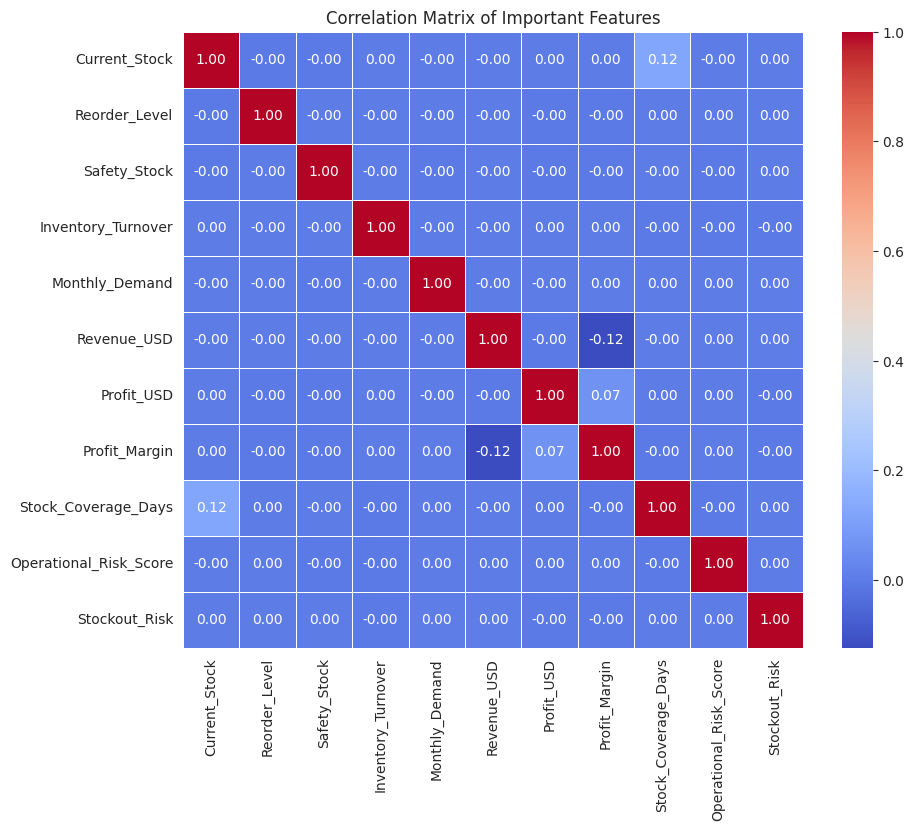

In [35]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Important Features")

plt.show()

### Insight

The correlation matrix shows that most numerical features have very weak linear relationships with each other. This indicates that the dataset has low multicollinearity, allowing the predictive model to learn from multiple independent features rather than relying on highly correlated variables.

# 6.5 Distribution of Warehouses by Revenue

In [36]:
warehouse_revenue = (
    df.groupby("Warehouse_ID", as_index=False)["Revenue_USD"]
      .sum()
      .sort_values(by="Revenue_USD", ascending=False)
      .head(10)
)

fig = px.bar(
    warehouse_revenue,
    x="Warehouse_ID",
    y="Revenue_USD",
    color="Revenue_USD",
    text="Revenue_USD",
    title="Top 10 Warehouses by Revenue",
    color_continuous_scale="Viridis"
)

fig.update_traces(textposition="outside")

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    coloraxis_showscale=False
)

fig.show()

### Insight

The chart highlights the warehouses generating the highest revenue. Identifying top-performing warehouses helps management evaluate operational efficiency and prioritize inventory allocation.

# 7 Feature Selection

In [37]:
df["Daily_Demand"].describe()

,Daily_Demand
count,200000.000000
mean,249.691480
std,144.627209
min,0.000000
25%,124.000000
50%,249.000000
75%,375.000000
max,499.000000


In [38]:
numeric_df = df.select_dtypes(include="number")

target_corr = (
    numeric_df.corr()["Daily_Demand"]
    .drop("Daily_Demand")
    .sort_values(key=abs, ascending=False)
)

target_corr

,Daily_Demand
Stock_Coverage_Days,-0.257514
Supplier_Performance_Score,0.009768
Utilization_Rate,-0.005053
Monthly_Demand,0.004927
Lead_Time_Days,-0.004429
Supply_Disruption_Risk,0.004321
Current_Stock,0.003949
Seasonal_Demand_Index,-0.003864
Inventory_Turnover,0.003232
Product_Cost_USD,0.002575


In [39]:
features = [
    "Current_Stock",
    "Reorder_Level",
    "Safety_Stock",
    "Inventory_Turnover",
    "Supplier_Rating",
    "Lead_Time_Days",
    "Seasonal_Demand_Index",
    "Inventory_Optimization_Score",
    "Supplier_Performance_Score",
    "Supply_Chain_Efficiency",
    "Operational_Risk_Score",
    "Revenue_Per_Unit"
]

target = "Daily_Demand"

In [40]:
X = df[features]
y = df[target]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (200000, 12)
Target Shape: (200000,)


# 8 Train-Test Split

In [41]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [42]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160000, 12)
(40000, 12)
(160000,)
(40000,)


# 9 Model Building

In [43]:
model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=5, min_samples_leaf=2,
                          min_samples_split=5, n_estimators=200,
                          random_state=42)

In [44]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
11,Revenue_Per_Unit,0.106291
8,Supplier_Performance_Score,0.100005
10,Operational_Risk_Score,0.093777
6,Seasonal_Demand_Index,0.092312
9,Supply_Chain_Efficiency,0.091547
7,Inventory_Optimization_Score,0.085082
0,Current_Stock,0.082806
3,Inventory_Turnover,0.078845
1,Reorder_Level,0.077271
2,Safety_Stock,0.075740


In [45]:


fig = px.bar(
    feature_importance.head(15),
    x="Importance",
    y="Feature",
    orientation="h",
    title="Top 15 Features by Importance"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    yaxis={"categoryorder": "total ascending"}
)

fig.show()

# 10 Model Evaluation

In [46]:
y_pred = model.predict(X_test)

In [47]:



mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 3))




MAE: 125.25
RMSE: 144.64
R² Score: -0.001


In [48]:
target_range = y_test.max() - y_test.min()

performance = (1 - (mae / target_range)) * 100

print(f"Performance Score: {performance:.2f}%")

Performance Score: 74.90%


In [49]:


results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

fig = px.scatter(
    results.sample(1000, random_state=42),
    x="Actual",
    y="Predicted",
    title="Actual vs Predicted Daily Demand"
)

fig.add_shape(
    type="line",
    x0=results["Actual"].min(),
    y0=results["Actual"].min(),
    x1=results["Actual"].max(),
    y1=results["Actual"].max(),
    line=dict(dash="dash")
)

fig.show()

# 11: Actual vs Predicted

In [50]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,75,249.222969
1,224,244.174015
2,136,254.299506
3,344,255.682990
4,27,248.737826
5,147,248.273687
6,252,249.940918
7,160,281.924188
8,426,247.681582
9,352,250.371582


In [51]:
sample = comparison.sample(min(500, len(comparison)), random_state=42)

fig = px.scatter(
    sample,
    x="Actual",
    y="Predicted",
    title="Actual vs Predicted Daily Demand",
    opacity=0.6,
    trendline="ols"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Actual Daily Demand",
    yaxis_title="Predicted Daily Demand"
)

fig.show()

### Insight

 The scatter plot compares the actual Daily Demand values with the predicted values generated by the model. Points closer to the diagonal line indicate better prediction accuracy.

# Export Data

In [52]:
from google.colab import files

df.to_csv("Retail_Supply_Cleaned.csv", index=False)
files.download("Retail_Supply_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>